# Lab 4: Basic regression - Predict fuel efficiency



## Imports

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # we use this library to load the dataset
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

## Load data

In [102]:
# Load the 'mpg' dataset using seaborn library into a Pandas DataFrame
df = sns.load_dataset('mpg')

MPG dataset can be viewed online at  
https://github.com/mwaskom/seaborn-data/blob/master/mpg.csv

## Data Exploration - Pandas Review

### Show the first 5 rows of the dataset

In [103]:
#your code here
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


### Show the size of the dataframe

In [104]:
#your code here
df.size, df.shape

(3582, (398, 9))

### Find the columns name and their types (numerical or categorical)

In [105]:
#your code here
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin', 'name'],
      dtype='object')

In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [107]:
df.dtypes

,0
mpg,float64
cylinders,int64
displacement,float64
horsepower,float64
weight,int64
acceleration,float64
model_year,int64
origin,object
name,object


### Find the number of missing values in each column

In [108]:
#your code here
df.isna().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
name,0


### Handle the missing values in the dataframe

Since the number of missing values is low, we can simply drop the rows containing them. However, as a practice and review, let's substitute the missing values in the numerical columns (if any) with the mean of the respective column and the missing values in the categorical columns (if any) with the median of the respective column.

In [109]:
#your solution here
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].mean())

### Compute the average and the median weight

In [110]:
#your code here
int(df['weight'].mean())

2970

In [111]:
int(df['weight'].median())

2803

<Axes: >

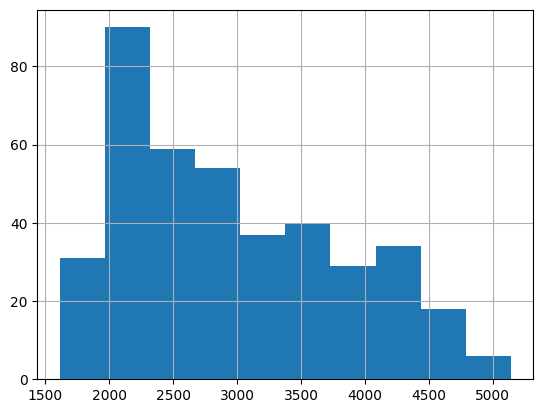

In [112]:
df['weight'].hist()

### Find the number of cars that weight more than 2000 kgs

In [113]:
#your code here
mask = df['weight'] > 2000
df[mask]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


### Find how many cars there are for each number of cylinders

In [114]:
#your code here
df['cylinders'].value_counts()

,count
cylinders,
4,204
8,103
6,84
3,4
5,3


### Find what are the car models with number of cylinders (3 or 5)

In [115]:
#your code here
mask = (df['cylinders'] == 3) | (df['cylinders'] == 5)
df[mask]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
71,19.0,3,70.0,97.0,2330,13.5,72,japan,mazda rx2 coupe
111,18.0,3,70.0,90.0,2124,13.5,73,japan,maxda rx3
243,21.5,3,80.0,110.0,2720,13.5,77,japan,mazda rx-4
274,20.3,5,131.0,103.0,2830,15.9,78,europe,audi 5000
297,25.4,5,183.0,77.0,3530,20.1,79,europe,mercedes benz 300d
327,36.4,5,121.0,67.0,2950,19.9,80,europe,audi 5000s (diesel)
334,23.7,3,70.0,100.0,2420,12.5,80,japan,mazda rx-7 gs


### Show the `value_counts()` of `origin` column or show the unique values of this column.

In [116]:
#your code here
df['origin'].value_counts()

,count
origin,
usa,249
japan,79
europe,70


In [117]:
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


## Data Preprocessing

### Use one hot encoding to change the categorical values of `origin` column to numerical values.

- use `pd.get_dummies()` method to do the encoding
- Join the original DataFrame with the new dummy DataFrame with `pd.concat()` and use `axis=1` to concate in horizontal direction.

In [118]:
dummies = pd.get_dummies(df['origin'], dtype=float)
dummies

,europe,japan,usa
0,0.0,0.0,1.0
1,0.0,0.0,1.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0
...,...,...,...
393,0.0,0.0,1.0
394,1.0,0.0,0.0
395,0.0,0.0,1.0
396,0.0,0.0,1.0


### Remove the `name` and `origin` column form the dataframe to have all numerical dataframe.

In [119]:
#your code here
df_concat = pd.concat([df, dummies], axis=1)
df_concat

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,europe,japan,usa
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu,0.0,0.0,1.0
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320,0.0,0.0,1.0
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite,0.0,0.0,1.0
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst,0.0,0.0,1.0
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl,0.0,0.0,1.0
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup,1.0,0.0,0.0
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage,0.0,0.0,1.0
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger,0.0,0.0,1.0


In [120]:
df_processed = df_concat.drop(columns=["origin", "name"])
df_processed

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,europe,japan,usa
0,18.0,8,307.0,130.0,3504,12.0,70,0.0,0.0,1.0
1,15.0,8,350.0,165.0,3693,11.5,70,0.0,0.0,1.0
2,18.0,8,318.0,150.0,3436,11.0,70,0.0,0.0,1.0
3,16.0,8,304.0,150.0,3433,12.0,70,0.0,0.0,1.0
4,17.0,8,302.0,140.0,3449,10.5,70,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,0.0,0.0,1.0
394,44.0,4,97.0,52.0,2130,24.6,82,1.0,0.0,0.0
395,32.0,4,135.0,84.0,2295,11.6,82,0.0,0.0,1.0
396,28.0,4,120.0,79.0,2625,18.6,82,0.0,0.0,1.0


### Does the input needs reshaping?

In [121]:
#your code here


### Form features `X` and labels `y` based on the processed datafram

In [122]:
df_processed.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'europe', 'japan', 'usa'],
      dtype='object')

In [123]:
#your code here
X = df_processed[['cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'europe', 'japan', 'usa']]
y = df_processed['mpg']

In [124]:
X.shape, y.shape

((398, 9), (398,))

### Split the data into training and test sets and form `train_features`, `train_labels`, `test_features`, `test_labels`

In [125]:
from sklearn.model_selection import train_test_split
#your code here

train_features, test_features, train_labels, test_labels = train_test_split(X, y, test_size=0.2, random_state=42)

In [126]:
train_features.shape, test_features.shape, train_labels.shape, test_labels.shape

((318, 9), (80, 9), (318,), (80,))

In [127]:
train_features

,cylinders,displacement,horsepower,weight,acceleration,model_year,europe,japan,usa
3,8,304.0,150.0,3433,12.0,70,0.0,0.0,1.0
18,4,97.0,88.0,2130,14.5,70,0.0,1.0,0.0
376,4,91.0,68.0,2025,18.2,82,0.0,1.0,0.0
248,4,91.0,60.0,1800,16.4,78,0.0,1.0,0.0
177,4,115.0,95.0,2694,15.0,75,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
71,3,70.0,97.0,2330,13.5,72,0.0,1.0,0.0
106,8,350.0,180.0,4499,12.5,73,0.0,0.0,1.0
270,4,134.0,95.0,2515,14.8,78,0.0,1.0,0.0
348,4,89.0,62.0,2050,17.3,81,0.0,1.0,0.0


### For simplicity in the following steps, convert the dataset from a pandas DataFrame to a numpy array.

In [128]:
train_features = np.array(train_features)
train_labels = np.array(train_labels)
test_features = np.array(test_features)
test_labels = np.array(test_labels)

### Do some sanity check on the shape of the data before building a model

In [129]:
# your code here
train_features.shape, test_features.shape, train_labels.shape, test_labels.shape

((318, 9), (80, 9), (318,), (80,))

## Normalization layer

To ensure stable training of neural networks, we typically normalize the data. This process also enhances the convergence of the gradient descent algorithm.

There is not single way to normalize the data. You can also use `scikit-learn `or `pandas` to do it. However, in this lab, we will use the normalization layer provided by tensorflow which matches the other parts of the model.

The `tf.keras.layers.Normalization` is a clean and simple way to add feature normalization into your model.

The first step is to create the layer:

In [130]:
normalizer = tf.keras.layers.Normalization(axis=-1)

Then, fit the state of the preprocessing layer to the data by calling `Normalization.adapt`.

It calculates the mean and variance of each feature, and store them in the layer

In [131]:
normalizer.adapt(train_features)

When the layer is called, it returns the input data, with each feature independently normalized.

In [132]:
first = train_features[0]
print('First example:', first)
print()
print('Normalized:', normalizer(first).numpy())

First example: [8.000e+00 3.040e+02 1.500e+02 3.433e+03 1.200e+01 7.000e+01 0.000e+00
 0.000e+00 1.000e+00]

Normalized: [[ 1.5271883   1.0901965   1.2618345   0.55282634 -1.3193338  -1.6966677
  -0.46232074 -0.5117663   0.7889544 ]]


## **Approach #1:** Regression using `Linear Regression`

**You are welcome to use scikit-learn to perform linear regression on this dataset.**

However, here we aim to implement it using TensorFlow.

- As we saw in Lab Week 2, `logistic regression` is essentially a single neuron with a `sigmoid` activation function.

- Similarly, `linear regression` can be viewed as a single neuron with a `linear` activation function.

### **Step 1:** Linear regression model architecture

In [133]:
linear_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(9,)),
    normalizer,
    layers.Dense(1, activation='linear')
])

**Note:** You can define your model all at once like the cell above or you can buid the model incrementaly  (suitable for your assignment)

In [134]:
# Defining the model incrementaly (suitable for your assignment)
linear_model = tf.keras.Sequential()
linear_model.add(tf.keras.layers.Input(shape=(9,)))
linear_model.add(normalizer)
linear_model.add(layers.Dense(1, activation='linear'))

### **Step 2:** Configure the model with Keras `Model.compile()`

The most important arguments to compile are the `loss` and the `optimizer`, since these define what will be optimized (`"mean_absolute_error"`) and how (using the `tf.keras.optimizers.Adam(learning_rate=0.1)`).

**arguments:**
- optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
- loss='mean_absolute_error'

In [135]:
#your code here
linear_model.compile(loss="mean_absolute_error",
                     optimizer=tf.keras.optimizers.Adam(learning_rate=0.1)
                     )

### **Step 3:** Train the model using the `Model.fit()` for `100` epochs, and store the output in a variable named history.

In [136]:
history = linear_model.fit(train_features, train_labels, epochs=100, batch_size=32)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 22.6880
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22.1191  
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 21.4206 
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 20.5006 
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 19.0376 
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 18.5193 
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 17.2652 
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 16.2909 
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 15.3536 
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 14.2526 
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13.2836 
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13.1817 
Epoch 13/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 11.0766 
Epoch 14/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 10.3692 
Epoch 15/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s

In [137]:
history.history

{'loss': [23.234813690185547,
  22.18718719482422,
  21.174955368041992,
  20.176021575927734,
  19.19432830810547,
  18.18421745300293,
  17.171377182006836,
  16.17817497253418,
  15.190414428710938,
  14.190836906433105,
  13.222606658935547,
  12.214054107666016,
  11.205241203308105,
  10.216198921203613,
  9.214561462402344,
  8.263883590698242,
  7.295828342437744,
  6.361118316650391,
  5.520742893218994,
  4.768857479095459,
  4.067678928375244,
  3.5422136783599854,
  3.1395606994628906,
  2.9148950576782227,
  2.7722339630126953,
  2.716087579727173,
  2.6661150455474854,
  2.609031915664673,
  2.6093554496765137,
  2.5998873710632324,
  2.579385995864868,
  2.595233917236328,
  2.5664403438568115,
  2.5675196647644043,
  2.5612289905548096,
  2.6055386066436768,
  2.563591241836548,
  2.569427490234375,
  2.5531818866729736,
  2.5800817012786865,
  2.5562188625335693,
  2.6134376525878906,
  2.5841896533966064,
  2.549985408782959,
  2.5594751834869385,
  2.5609569549560547

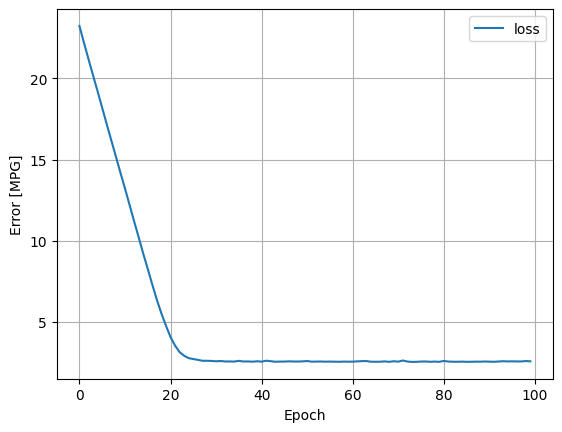

In [138]:
def plot_loss(history):
  plt.plot(history.history['loss'], label='loss')
  plt.xlabel('Epoch')
  plt.ylabel('Error [MPG]')
  plt.legend()
  plt.grid(True)

plot_loss(history)

### Get the model summary

In [139]:
linear_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_2 (Normalization) │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (212.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 19 (80.00 B)

 Optimizer params: 22 (92.00 B)

### **Step 4:** Evaluate the linear model on the test set using Keras `Model.evaluate()` and see the `mean_absolute_error` and save the result for future comparison.

In [146]:
#your code here
linear_test_loss = linear_model.evaluate(test_features, test_labels, verbose=0)
print(f"Linear Model - Test MAE: {linear_test_loss:.2f}")

Linear Model - Test MAE: 2.15


## **Approach #2:** Regression using a `Deep Neural Network (DNN)`

### Solve the same problem and using deep neural network with the sample architecture;
- 1st hidden layer no. of units =  64
- 2nd hidden layer no. of units = 64
- Choose appropriate `activation` functions for hidden and output layers

In [150]:
#your code here
dnn_model = tf.keras.Sequential([
    normalizer,
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='linear')
])

dnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_absolute_error'
)

history_dnn = dnn_model.fit(
    train_features,
    train_labels,
    epochs=100,
    batch_size=32,
    verbose=0
)


### Print the model summary (after training). How many parameters are there in the model?

In [151]:
#your code here
dnn_model.summary()

total_params = dnn_model.count_params()
print(f"\nTotal trainable parameters: {total_params}")

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_2 (Normalization) │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,616 (57.10 KB)

 Trainable params: 4,865 (19.00 KB)

 Non-trainable params: 19 (80.00 B)

 Optimizer params: 9,732 (38.02 KB)


Total trainable parameters: 4884


## Compare the evaluation result of the two approaches, i.e., linear regression and deep neural network.

In [152]:
#your code here
dnn_test_loss = dnn_model.evaluate(test_features, test_labels, verbose=0)

print("=" * 50)
print("MODEL COMPARISON")
print("=" * 50)
print(f"Linear Regression - Test MAE: {linear_test_loss:.2f} MPG")
print(f"DNN Model         - Test MAE: {dnn_test_loss:.2f} MPG")
print("=" * 50)

if dnn_test_loss < linear_test_loss:
    improvement = ((linear_test_loss - dnn_test_loss) / linear_test_loss) * 100
    print(f"DNN is better by {improvement:.1f}%")
else:
    print("Linear regression performed better or similar")

MODEL COMPARISON
Linear Regression - Test MAE: 2.15 MPG
DNN Model         - Test MAE: 1.48 MPG
DNN is better by 31.4%


## Use the following large model and evaluate it on the test set.

In [144]:
model_dnn_large = tf.keras.Sequential([
    normalizer,
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='linear')
])


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_2 (Normalization) │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,576 (154.60 KB)

 Trainable params: 13,185 (51.50 KB)

 Non-trainable params: 19 (80.00 B)

 Optimizer params: 26,372 (103.02 KB)


Large DNN Model - Test MAE: 1.61 MPG

FINAL COMPARISON
Linear Regression - Test MAE: 2.15 MPG
Standard DNN      - Test MAE: 1.48 MPG
Large DNN         - Test MAE: 1.61 MPG


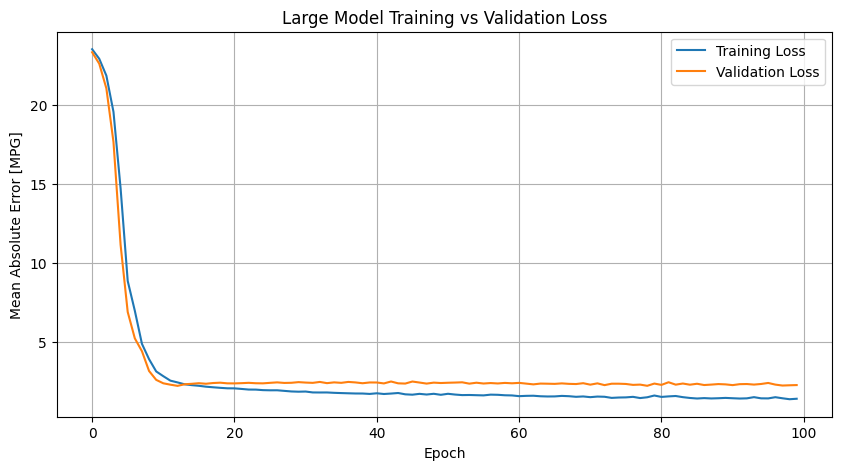

In [153]:
# your code here
model_dnn_large.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_absolute_error'
)

history_large = model_dnn_large.fit(
    train_features,
    train_labels,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

large_test_loss = model_dnn_large.evaluate(test_features, test_labels, verbose=0)

model_dnn_large.summary()
print(f"\nLarge DNN Model - Test MAE: {large_test_loss:.2f} MPG")

print("\n" + "=" * 50)
print("FINAL COMPARISON")
print("=" * 50)
print(f"Linear Regression - Test MAE: {linear_test_loss:.2f} MPG")
print(f"Standard DNN      - Test MAE: {dnn_test_loss:.2f} MPG")
print(f"Large DNN         - Test MAE: {large_test_loss:.2f} MPG")
print("=" * 50)

plt.figure(figsize=(10, 5))
plt.plot(history_large.history['loss'], label='Training Loss')
plt.plot(history_large.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error [MPG]')
plt.title('Large Model Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

### Explain your observation. Why do you think the large model is not performing well?

- hint: when the number of trainable parameters is very large (even larger than the number of data points), the model may overfit the training data. One way to solve this problem is to use more data.

The large model has significantly more parameters than data points:

Training samples: 318
Large model parameters: ~17,000+ (you can check with model_dnn_large.count_params())

This creates overfitting where:

The model memorizes training data instead of learning generalizable patterns
It performs well on training data but poorly on test data
The validation loss increases while training loss decreases (visible in the plot)

Solutions:

Use more training data
Use a simpler model architecture